<a href="https://colab.research.google.com/github/NatGN/Practicas-de-seminario-de-mineria-de-datos/blob/main/REGRESI%C3%93N_LINEALEjer2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score #Metricas de evaluación

In [2]:
#Carga y exploración inicial de datos
df = pd.read_csv('EdadSeguros.csv')
df.head()

,Edad,Costo
0,18,22
1,22,24
2,23,55
3,25,27
4,27,85


In [3]:
# Limpiar nombres de columnas por si tienen espacios en blanco
df.columns = [c.strip() for c in df.columns]

In [4]:
#Información Básica del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Edad    80 non-null     int64
 1   Costo   80 non-null     int64
dtypes: int64(2)
memory usage: 1.4 KB


In [5]:
#Estadisticas descriptivas para entender la distribucion
df.describe()

,Edad,Costo
count,80.00000,80.000000
mean,53.75000,52.162500
std,15.38987,24.120186
min,18.00000,5.000000
25%,42.75000,35.000000
50%,56.00000,55.000000
75%,66.00000,65.750000
max,79.00000,96.000000


In [6]:
#Preparación de los datos
#Seleccionamos las variables:
#X: independiente (predictora) - Edad
#y: dependiente (a predecir) - Costo

#Extraemos los valores como arrays de numpy para el modelo
X = df[['Edad']].values  # Variable independiente
y = df['Costo'].values       # Variable dependiente


In [7]:
# 2. Entrenar el modelo
modelo_seguros = LinearRegression()
modelo_seguros.fit(X, y)
y_pred = modelo_seguros.predict(X)

In [8]:
# Parámetros
m = modelo_seguros.coef_[0]
b = modelo_seguros.intercept_

In [9]:
from scipy import stats

# 3. Cálculo de Intervalos de Confianza (95%)
n = len(X)
dof = n - 2
t_val = stats.t.ppf(0.975, dof)
residuals = y - y_pred
std_error = np.sqrt(np.sum(residuals**2) / dof)

In [10]:
# Error estándar para la banda de confianza
x_mean = np.mean(X)
sum_sq_diff_x = np.sum((X - x_mean)**2)
se_band = std_error * np.sqrt(1/n + (X - x_mean)**2 / sum_sq_diff_x)


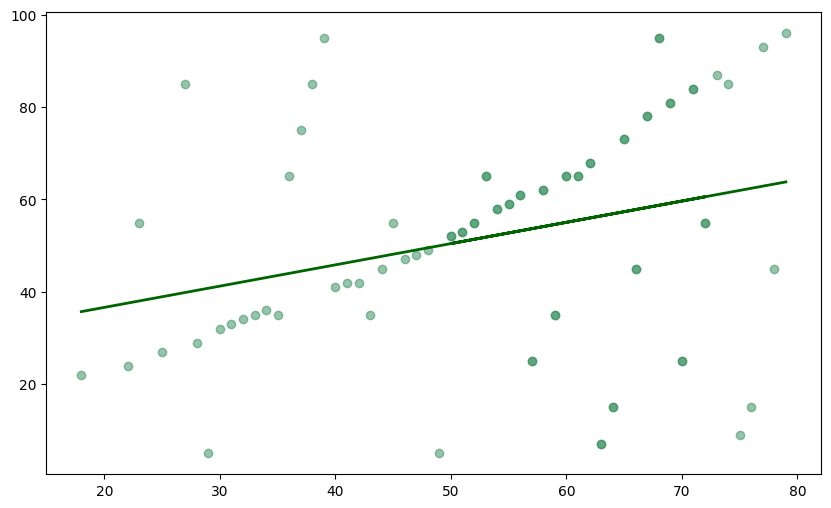

In [11]:
# 4. Visualización Profesional
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='seagreen', alpha=0.5, label='Clientes Reales')
plt.plot(X, y_pred, color='darkgreen', linewidth=2, label='Tendencia Lineal')

<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_436/2606006206.py:13: SyntaxWarning: invalid escape sequence '\c'
  plt.text(X.min(), y.max()*0.95, f'$Costo = {m:.2f} \cdot Edad + {b:.2f}$',


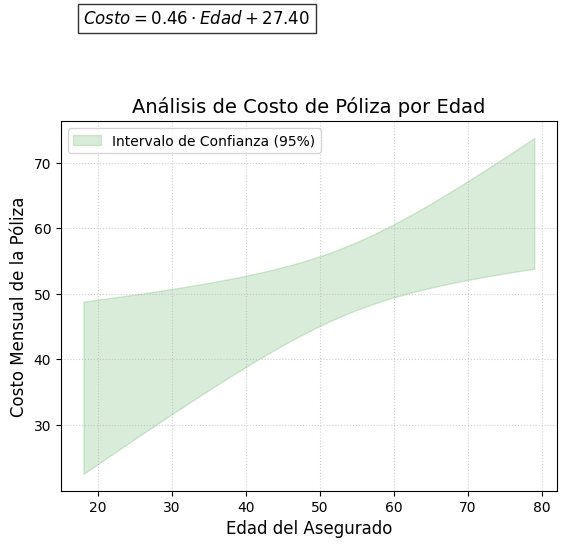

In [12]:
# Dibujar intervalo de confianza (sombreado)
orden = np.argsort(X.flatten())
plt.fill_between(X.flatten()[orden],
                 (y_pred - t_val * se_band.flatten())[orden],
                 (y_pred + t_val * se_band.flatten())[orden],
                 color='green', alpha=0.15, label='Intervalo de Confianza (95%)')

plt.title('Análisis de Costo de Póliza por Edad', fontsize=14)
plt.xlabel('Edad del Asegurado', fontsize=12)
plt.ylabel('Costo Mensual de la Póliza', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.text(X.min(), y.max()*0.95, f'$Costo = {m:.2f} \cdot Edad + {b:.2f}$',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.show()

In [13]:
# 5. Generar Tabla de Predicciones
edades_interes = np.array([30, 40, 50, 60]).reshape(-1, 1)
predicciones = modelo_seguros.predict(edades_interes)

tabla = pd.DataFrame({
    'Edad': [30, 40, 50, 60],
    'Costo Estimado ($)': predicciones.round(2)
})

print("--- Tabla de Costos Estimados ---")
print(tabla.to_string(index=False))

--- Tabla de Costos Estimados ---
 Edad  Costo Estimado ($)
   30               41.22
   40               45.83
   50               50.43
   60               55.04
